In [28]:
import pandas as pd
import numpy as np
from sklearn.utils import resample
import os
import joblib

In [29]:
# 1. Load data using the provided relative paths
X_train = pd.read_csv(r'C:\Users\Meet\Desktop\NLP-ASS-2\Group3\data\processed/X_train.csv')
X_val   = pd.read_csv(r'C:\Users\Meet\Desktop\NLP-ASS-2\Group3\data\processed/X_val.csv')
X_test  = pd.read_csv(r'C:\Users\Meet\Desktop\NLP-ASS-2\Group3\data\processed/X_test.csv')
y_train = pd.read_csv(r'C:\Users\Meet\Desktop\NLP-ASS-2\Group3\data\processed/y_train.csv').values.ravel()
y_val   = pd.read_csv(r'C:\Users\Meet\Desktop\NLP-ASS-2\Group3\data\processed/y_val.csv').values.ravel()
y_test  = pd.read_csv(r'C:\Users\Meet\Desktop\NLP-ASS-2\Group3\data\processed/y_test.csv').values.ravel()

# Convert y arrays to DataFrame for easier concatenation
y_train = pd.DataFrame({'label': y_train})
y_val   = pd.DataFrame({'label': y_val})
y_test  = pd.DataFrame({'label': y_test})

# Display shapes
print("Shapes:")
print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val:  ", X_val.shape,   "y_val:  ", y_val.shape)
print("X_test: ", X_test.shape,  "y_test: ", y_test.shape)


Shapes:
X_train: (270798, 4) y_train: (270798, 1)
X_val:   (90266, 4) y_val:   (90266, 1)
X_test:  (90267, 4) y_test:  (90267, 1)


In [30]:
# 2. Check for missing values
print("\nMissing values per split (before dropping):")
print("X_train nulls:\n", X_train.isnull().sum())
print("y_train nulls:\n", y_train.isnull().sum())
print("X_val nulls:\n",   X_val.isnull().sum())
print("y_val nulls:\n",   y_val.isnull().sum())
print("X_test nulls:\n",  X_test.isnull().sum())
print("y_test nulls:\n",  y_test.isnull().sum())



Missing values per split (before dropping):
X_train nulls:
 clean_tweet      6680
tweet_length        0
num_hashtags        0
lexicon_score       0
dtype: int64
y_train nulls:
 label    0
dtype: int64
X_val nulls:
 clean_tweet      2186
tweet_length        0
num_hashtags        0
lexicon_score       0
dtype: int64
y_val nulls:
 label    0
dtype: int64
X_test nulls:
 clean_tweet      2250
tweet_length        0
num_hashtags        0
lexicon_score       0
dtype: int64
y_test nulls:
 label    0
dtype: int64


In [31]:
# Drop any rows in X or y where either is null
def drop_null_rows(X, y):
    df = pd.concat([X, y], axis=1)
    df_clean = df.dropna()
    return df_clean.iloc[:, :-1].reset_index(drop=True), df_clean['label'].reset_index(drop=True)

X_train, y_train = drop_null_rows(X_train, y_train)
X_val,   y_val   = drop_null_rows(X_val,   y_val)
X_test,  y_test  = drop_null_rows(X_test,  y_test)

print("\nAfter dropping nulls:")
print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val:  ", X_val.shape,   "y_val:  ", y_val.shape)
print("X_test: ", X_test.shape,  "y_test: ", y_test.shape)


After dropping nulls:
X_train: (264118, 4) y_train: (264118,)
X_val:   (88080, 4) y_val:   (88080,)
X_test:  (88017, 4) y_test:  (88017,)


In [32]:
# 3. Check for duplicate texts within each split
print("\nDuplicates within each split (before removal):")
print("X_train duplicates:", X_train.duplicated().sum())
print("X_val duplicates:  ",   X_val.duplicated().sum())
print("X_test duplicates: ",   X_test.duplicated().sum())



Duplicates within each split (before removal):
X_train duplicates: 29301
X_val duplicates:   6230
X_test duplicates:  6307


In [33]:
# Remove duplicates within each split (keep first occurrence)
X_train = X_train.drop_duplicates().reset_index(drop=True)
X_val   = X_val.drop_duplicates().reset_index(drop=True)
X_test  = X_test.drop_duplicates().reset_index(drop=True)

# Realign y_train, y_val, y_test after dropping duplicates
y_train = y_train.loc[X_train.index].reset_index(drop=True)
y_val   = y_val.loc[X_val.index].reset_index(drop=True)
y_test  = y_test.loc[X_test.index].reset_index(drop=True)

print("\nAfter removing within-split duplicates:")
print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val:  ", X_val.shape,   "y_val:  ", y_val.shape)
print("X_test: ", X_test.shape,  "y_test: ", y_test.shape)


After removing within-split duplicates:
X_train: (234817, 4) y_train: (234817,)
X_val:   (81850, 4) y_val:   (81850,)
X_test:  (81710, 4) y_test:  (81710,)


In [34]:
# 4. Check for overlap between splits (data leakage)
train_texts = set(X_train.iloc[:, 0].astype(str))
val_texts   = set(X_val.iloc[:, 0].astype(str))
test_texts  = set(X_test.iloc[:, 0].astype(str))

overlap_train_val = train_texts.intersection(val_texts)
overlap_train_test = train_texts.intersection(test_texts)
overlap_val_test   = val_texts.intersection(test_texts)

print("\nOverlap counts (before removal):")
print("Train/Val overlap:", len(overlap_train_val))
print("Train/Test overlap:", len(overlap_train_test))
print("Val/Test overlap:", len(overlap_val_test))



Overlap counts (before removal):
Train/Val overlap: 9626
Train/Test overlap: 9753
Val/Test overlap: 5985


In [35]:
def remove_overlap(X_source, y_source, overlap_set):
    mask = ~X_source.iloc[:, 0].astype(str).isin(overlap_set)
    return X_source[mask].reset_index(drop=True), y_source[mask].reset_index(drop=True)

if overlap_train_val:
    X_val, y_val = remove_overlap(X_val, y_val, overlap_train_val)
if overlap_train_test:
    X_test, y_test = remove_overlap(X_test, y_test, overlap_train_test)
if overlap_val_test:
    X_test, y_test = remove_overlap(X_test, y_test, overlap_val_test)

print("\nAfter removing overlaps:")
print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val:  ", X_val.shape,   "y_val:  ", y_val.shape)
print("X_test: ", X_test.shape,  "y_test:", y_test.shape)


After removing overlaps:
X_train: (234817, 4) y_train: (234817,)
X_val:   (68234, 4) y_val:   (68234,)
X_test:  (66860, 4) y_test: (66860,)


In [36]:
import pandas as pd
from sklearn.utils import resample

# 1) LOAD RAW DATA
X_train = pd.read_csv(r'C:\Users\Meet\Desktop\NLP-ASS-2\Group3\data\processed/X_train.csv')
X_val   = pd.read_csv(r'C:\Users\Meet\Desktop\NLP-ASS-2\Group3\data\processed/X_val.csv')
X_test  = pd.read_csv(r'C:\Users\Meet\Desktop\NLP-ASS-2\Group3\data\processed/X_test.csv')

y_train = pd.read_csv(r'C:\Users\Meet\Desktop\NLP-ASS-2\Group3\data\processed/y_train.csv', header=None).iloc[:, 0]
y_val   = pd.read_csv(r'C:\Users\Meet\Desktop\NLP-ASS-2\Group3\data\processed/y_val.csv',   header=None).iloc[:, 0]
y_test  = pd.read_csv(r'C:\Users\Meet\Desktop\NLP-ASS-2\Group3\data\processed/y_test.csv',  header=None).iloc[:, 0]

# Wrap into pandas Series named "label" (and drop any non‐numeric rows if they exist)
y_train = pd.Series(pd.to_numeric(y_train, errors='coerce')).dropna().astype(int).reset_index(drop=True).rename('label')
y_val   = pd.Series(pd.to_numeric(y_val,   errors='coerce')).dropna().astype(int).reset_index(drop=True).rename('label')
y_test  = pd.Series(pd.to_numeric(y_test,  errors='coerce')).dropna().astype(int).reset_index(drop=True).rename('label')

# 1a) CHECK LENGTHS AND TRIM IF NECESSARY
print("Before alignment:")
print("  len(X_train) =", len(X_train), " len(y_train) =", len(y_train))
print("  len(X_val)   =", len(X_val),   " len(y_val)   =", len(y_val))
print("  len(X_test)  =", len(X_test),  " len(y_test)  =", len(y_test))

# Trim the longer of each pair so they match
if len(y_train) > len(X_train):
    y_train = y_train.iloc[: len(X_train)].reset_index(drop=True)
elif len(X_train) > len(y_train):
    X_train = X_train.iloc[: len(y_train)].reset_index(drop=True)

if len(y_val) > len(X_val):
    y_val = y_val.iloc[: len(X_val)].reset_index(drop=True)
elif len(X_val) > len(y_val):
    X_val = X_val.iloc[: len(y_val)].reset_index(drop=True)

if len(y_test) > len(X_test):
    y_test = y_test.iloc[: len(X_test)].reset_index(drop=True)
elif len(X_test) > len(y_test):
    X_test = X_test.iloc[: len(y_test)].reset_index(drop=True)

print("After alignment:")
print("  len(X_train) =", len(X_train), " len(y_train) =", len(y_train))
print("  len(X_val)   =", len(X_val),   " len(y_val)   =", len(y_val))
print("  len(X_test)  =", len(X_test),  " len(y_test)  =", len(y_test))

# 2) MAP 5‐point labels → 3 classes (0,1→0; 2→1; 3,4→2)
def map_to_three_classes(s: pd.Series) -> pd.Series:
    return s.replace({0:0, 1:0, 2:1, 3:2, 4:2})

y_train_mapped = map_to_three_classes(y_train)
y_val_mapped   = map_to_three_classes(y_val)
y_test_mapped  = map_to_three_classes(y_test)

print("\nDistinct labels after mapping:")
print("  y_train_mapped.unique() =", sorted(y_train_mapped.unique()))
print("  Counts in y_train_mapped:\n", y_train_mapped.value_counts(), "\n")

# 3) STRICTLY FILTER OUT ANY ROWS NOT IN {0,1,2}
#    Build one DataFrame per split, filter by label, then split again.

train_df = X_train.copy()
train_df['label'] = y_train_mapped.values  # now both have same length
train_df = train_df[train_df['label'].isin([0,1,2])].reset_index(drop=True)

X_train = train_df.drop(columns=['label'])
y_train = train_df['label']

print("After filtering, TRAIN shape:", X_train.shape)
print("  y_train.value_counts():\n", y_train.value_counts(), "\n")

val_df = X_val.copy()
val_df['label'] = y_val_mapped.values
val_df = val_df[val_df['label'].isin([0,1,2])].reset_index(drop=True)

X_val = val_df.drop(columns=['label'])
y_val = val_df['label']
print("After filtering, VAL shape:", X_val.shape)
print("  y_val.value_counts():\n", y_val.value_counts(), "\n")

test_df = X_test.copy()
test_df['label'] = y_test_mapped.values
test_df = test_df[test_df['label'].isin([0,1,2])].reset_index(drop=True)

X_test = test_df.drop(columns=['label'])
y_test = test_df['label']
print("After filtering, TEST shape:", X_test.shape)
print("  y_test.value_counts():\n", y_test.value_counts(), "\n")

# 4) DROP ANY NaNs IN FEATURES OR LABELS (just in case)
def drop_null_rows(X: pd.DataFrame, y: pd.Series):
    df = pd.concat([X, y], axis=1)
    df_clean = df.dropna()
    return df_clean.iloc[:, :-1].reset_index(drop=True), df_clean['label'].reset_index(drop=True)

X_train, y_train = drop_null_rows(X_train, y_train)
X_val,   y_val   = drop_null_rows(X_val,   y_val)
X_test,  y_test  = drop_null_rows(X_test,  y_test)

print("After dropping NaNs:")
print("  TRAIN:", X_train.shape, y_train.shape)
print("  VAL:  ", X_val.shape,   y_val.shape)
print("  TEST: ", X_test.shape,  y_test.shape)

# 5) REMOVE DUPLICATE TWEETS WITHIN EACH SPLIT
#    (Assuming the text column is 'clean_tweet'.)
train_df = pd.concat([X_train, y_train], axis=1).drop_duplicates(subset=['clean_tweet']).reset_index(drop=True)
X_train = train_df.drop(columns=['label'])
y_train = train_df['label']

val_df = pd.concat([X_val, y_val], axis=1).drop_duplicates(subset=['clean_tweet']).reset_index(drop=True)
X_val = val_df.drop(columns=['label'])
y_val = val_df['label']

test_df = pd.concat([X_test, y_test], axis=1).drop_duplicates(subset=['clean_tweet']).reset_index(drop=True)
X_test = test_df.drop(columns=['label'])
y_test = test_df['label']

print("\nAfter removing duplicates:")
print("  TRAIN:", X_train.shape, y_train.shape)
print("  VAL:  ", X_val.shape,   y_val.shape)
print("  TEST: ", X_test.shape,  y_test.shape)

# 6) REMOVE OVERLAP (DATA LEAKAGE) ACROSS SPLITS
train_texts = set(X_train['clean_tweet'])
val_texts   = set(X_val['clean_tweet'])
test_texts  = set(X_test['clean_tweet'])

overlap_train_val  = train_texts.intersection(val_texts)
overlap_train_test = train_texts.intersection(test_texts)
overlap_val_test   = val_texts.intersection(test_texts)

print("\nOverlap counts before removal:")
print("  Train/Val overlap:", len(overlap_train_val))
print("  Train/Test overlap:", len(overlap_train_test))
print("  Val/Test overlap:",   len(overlap_val_test))

def remove_overlap(X_split: pd.DataFrame, y_split: pd.Series, overlap_set: set):
    mask = ~X_split['clean_tweet'].isin(overlap_set)
    return X_split[mask].reset_index(drop=True), y_split[mask].reset_index(drop=True)

if overlap_train_val:
    X_val, y_val = remove_overlap(X_val, y_val, overlap_train_val)
if overlap_train_test:
    X_test, y_test = remove_overlap(X_test, y_test, overlap_train_test)
if overlap_val_test:
    X_test, y_test = remove_overlap(X_test, y_test, overlap_val_test)

print("\nAfter removing any cross‐split overlaps:")
print("  TRAIN:", X_train.shape, y_train.shape)
print("  VAL:  ", X_val.shape,   y_val.shape)
print("  TEST: ", X_test.shape,  y_test.shape)

# 7) CHECK CLASS DISTRIBUTION BEFORE BALANCING
print("\nDistribution BEFORE balancing (train):")
print(y_train.value_counts(), "\n")

# 8) BALANCE (OVERSAMPLE) THE THREE CLASSES IN TRAIN ONLY
train_df = pd.concat([X_train, y_train], axis=1)
majority_count = train_df['label'].value_counts().max()

balanced_frames = []
for cls in [0, 1, 2]:
    cls_df = train_df[train_df['label'] == cls]
    if cls_df.shape[0] < majority_count:
        cls_upsampled = resample(
            cls_df,
            replace=True,
            n_samples=majority_count,
            random_state=42
        )
        balanced_frames.append(cls_upsampled)
    else:
        balanced_frames.append(cls_df)

train_upsampled = pd.concat(balanced_frames).reset_index(drop=True)
train_upsampled = train_upsampled.sample(frac=1, random_state=42).reset_index(drop=True)

X_train_cleaned = train_upsampled.drop(columns=['label'])
y_train_cleaned = train_upsampled['label']

print("\nDistribution AFTER balancing (train):")
print(y_train_cleaned.value_counts(), "\n")

# 9) EXPOSE *_CLEANED VARIABLES FOR MODELING (in memory)
X_val_cleaned  = X_val.copy()
y_val_cleaned  = y_val.copy()
X_test_cleaned = X_test.copy()
y_test_cleaned = y_test.copy()

print("Final cleaned shapes:")
print(f"  X_train_cleaned: {X_train_cleaned.shape}, y_train_cleaned: {y_train_cleaned.shape}")
print(f"  X_val_cleaned:   {X_val_cleaned.shape},   y_val_cleaned:   {y_val_cleaned.shape}")
print(f"  X_test_cleaned:  {X_test_cleaned.shape},  y_test_cleaned:  {y_test_cleaned.shape}")


Before alignment:
  len(X_train) = 270798  len(y_train) = 270798
  len(X_val)   = 90266  len(y_val)   = 90266
  len(X_test)  = 90267  len(y_test)  = 90267
After alignment:
  len(X_train) = 270798  len(y_train) = 270798
  len(X_val)   = 90266  len(y_val)   = 90266
  len(X_test)  = 90267  len(y_test)  = 90267

Distinct labels after mapping:
  y_train_mapped.unique() = [0, 1, 2]
  Counts in y_train_mapped:
 2    165753
0     58836
1     46209
Name: label, dtype: int64 

After filtering, TRAIN shape: (270798, 4)
  y_train.value_counts():
 2    165753
0     58836
1     46209
Name: label, dtype: int64 

After filtering, VAL shape: (90266, 4)
  y_val.value_counts():
 2    55251
0    19612
1    15403
Name: label, dtype: int64 

After filtering, TEST shape: (90267, 4)
  y_test.value_counts():
 2    55252
0    19612
1    15403
Name: label, dtype: int64 

After dropping NaNs:
  TRAIN: (264118, 4) (264118,)
  VAL:   (88080, 4) (88080,)
  TEST:  (88017, 4) (88017,)

After removing duplicates:
  TRA

In [37]:
set(X_train_cleaned['clean_tweet']).intersection(X_val_cleaned['clean_tweet'])
set(X_train_cleaned['clean_tweet']).intersection(X_test_cleaned['clean_tweet'])
set(X_val_cleaned['clean_tweet']).intersection(X_test_cleaned['clean_tweet'])


set()

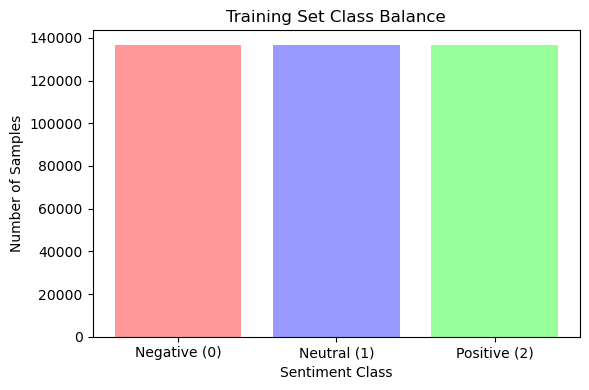

In [38]:
import matplotlib.pyplot as plt

# Assuming y_train_cleaned exists in the environment.
# Compute counts for each class
class_counts = y_train_cleaned.value_counts().sort_index()

# Map numeric labels to names
class_names = ['Negative (0)', 'Neutral (1)', 'Positive (2)']

# Plot bar chart
plt.figure(figsize=(6, 4))
plt.bar(class_names, class_counts.values, color=['#FF9999', '#9999FF', '#99FF99'])
plt.title('Training Set Class Balance')
plt.xlabel('Sentiment Class')
plt.ylabel('Number of Samples')
plt.tight_layout()
plt.show()


In [40]:
import numpy as np

def load_glove_embeddings(glove_path):
    """
    Reads the GloVe file and returns a dict: { word: 100-dim np.array }.
    """
    embeddings_index = {}
    with open(glove_path, encoding="utf8") as f:
        for line in f:
            parts = line.strip().split()
            word = parts[0]
            vec = np.asarray(parts[1:], dtype="float32")
            embeddings_index[word] = vec
    print(f"Loaded {len(embeddings_index)} GloVe word vectors.")
    return embeddings_index



In [41]:
    glove_index = load_glove_embeddings(r"C:\Users\Meet\Downloads\glove.6B\glove.6B.100d.txt")
EMBED_DIM = 100


Loaded 400000 GloVe word vectors.


In [42]:
def tweet_to_glove(text, embeddings_index, dim=EMBED_DIM):
    """
    Converts one cleaned tweet (string) into a 100-dim embedding by averaging
    the GloVe vectors for each token. If no token is in GloVe, returns zeros.
    """
    tokens = text.split()  # simple whitespace split
    valid_vecs = []
    for tok in tokens:
        vec = embeddings_index.get(tok)
        if vec is not None:
            valid_vecs.append(vec)
    if not valid_vecs:
        return np.zeros(dim, dtype="float32")
    return np.mean(valid_vecs, axis=0)

# Quick sanity check:
sample_text = X_train_cleaned["clean_tweet"].iloc[0]
print("Sample tweet:", sample_text)
print("Embedded shape:", tweet_to_glove(sample_text, glove_index).shape)


Sample tweet: interview freedom convoy commission jccf
Embedded shape: (100,)


In [43]:
import numpy as np

# 3a) Embed all tweets in TRAIN
X_train_emb = np.vstack([
    tweet_to_glove(txt, glove_index) 
    for txt in X_train_cleaned["clean_tweet"]
])
# 3b) Extract numeric features from TRAIN
nums_train = X_train_cleaned[["tweet_length", "num_hashtags", "lexicon_score"]].values

# 3c) Final train feature matrix: [100-dim embed | 3 numeric]
X_train_final = np.hstack([X_train_emb, nums_train])  # shape: (n_train, 103)

# Repeat for VAL
X_val_emb = np.vstack([
    tweet_to_glove(txt, glove_index) 
    for txt in X_val_cleaned["clean_tweet"]
])
nums_val = X_val_cleaned[["tweet_length", "num_hashtags", "lexicon_score"]].values
X_val_final = np.hstack([X_val_emb, nums_val])

# Repeat for TEST
X_test_emb = np.vstack([
    tweet_to_glove(txt, glove_index) 
    for txt in X_test_cleaned["clean_tweet"]
])
nums_test = X_test_cleaned[["tweet_length", "num_hashtags", "lexicon_score"]].values
X_test_final = np.hstack([X_test_emb, nums_test])

# Confirm shapes:
print("X_train_final shape:", X_train_final.shape)
print("X_val_final   shape:", X_val_final.shape)
print("X_test_final  shape:", X_test_final.shape)


X_train_final shape: (410052, 103)
X_val_final   shape: (67902, 103)
X_test_final  shape: (66599, 103)


In [44]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
# Fit only on TRAIN
scaler.fit(X_train_final)

# Transform TRAIN/VAL/TEST
X_train_scaled = scaler.transform(X_train_final)
X_val_scaled   = scaler.transform(X_val_final)
X_test_scaled  = scaler.transform(X_test_final)

# Confirm that TRAIN now has mean≈0 and std≈1 (for each of 103 dims)
print("TRAIN mean (first 5 dims):", np.round(X_train_scaled.mean(axis=0)[:5], 2))
print("TRAIN std  (first 5 dims):", np.round(X_train_scaled.std(axis=0)[:5], 2))


TRAIN mean (first 5 dims): [ 0.  0.  0.  0. -0.]
TRAIN std  (first 5 dims): [1. 1. 1. 1. 1.]


In [45]:
from sklearn.model_selection import train_test_split

# 1a) Stratified sample of 35 000 rows from the cleaned training set
X_sub, _, y_sub, _ = train_test_split(
    X_train_cleaned,
    y_train_cleaned,
    train_size=35000,
    stratify=y_train_cleaned,
    random_state=42
)

# 1b) Reset indices so they start at 0
X_train_sampled = X_sub.reset_index(drop=True)
y_train_sampled = y_sub.reset_index(drop=True)

# 1c) Sanity check: shapes and class distribution
print("X_train_sampled shape:", X_train_sampled.shape)
print("y_train_sampled shape:", y_train_sampled.shape) 

print("\nClass distribution in the 35 000-sample (counts):")
print(y_train_sampled.value_counts())

print("\nClass distribution (percentages):")
print((y_train_sampled.value_counts(normalize=True) * 100).round(2))


X_train_sampled shape: (35000, 4)
y_train_sampled shape: (35000,)

Class distribution in the 35 000-sample (counts):
1    11667
0    11667
2    11666
Name: label, dtype: int64

Class distribution (percentages):
1    33.33
0    33.33
2    33.33
Name: label, dtype: float64


In [46]:
import numpy as np

# (B) Assume glove_index (dict), EMBED_DIM = 100 are already loaded from earlier steps.

def tweet_to_glove(text, embeddings_index, dim=EMBED_DIM):
    tokens = text.split()
    vecs = []
    for tok in tokens:
        v = embeddings_index.get(tok)
        if v is not None:
            vecs.append(v)
    if not vecs:
        return np.zeros(dim, dtype="float32")
    return np.mean(vecs, axis=0)

def build_features(X_df):
    """
    Input: X_df with columns ['clean_tweet','tweet_length','num_hashtags','lexicon_score']
    Output: np.array of shape (n_samples, 103)
    """
    n = len(X_df)
    emb_matrix = np.zeros((n, EMBED_DIM), dtype="float32")
    for i, txt in enumerate(X_df["clean_tweet"]):
        emb_matrix[i] = tweet_to_glove(txt, glove_index)
    nums = X_df[["tweet_length","num_hashtags","lexicon_score"]].values.astype("float32")
    return np.hstack([emb_matrix, nums])

# 2a) Build features for the 35 000-sample
X_train_feat = build_features(X_train_sampled)

# 2b) Build features for the full VAL & TEST
X_val_feat   = build_features(X_val_cleaned)
X_test_feat  = build_features(X_test_cleaned)

print("Shapes before scaling:")
print("  X_train_feat (sampled):", X_train_feat.shape) 
print("  X_val_feat:", X_val_feat.shape)                  
print("  X_test_feat:", X_test_feat.shape)                


Shapes before scaling:
  X_train_feat (sampled): (35000, 103)
  X_val_feat: (67902, 103)
  X_test_feat: (66599, 103)


In [47]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X_train_feat) 

X_train_scaled = scaler.transform(X_train_feat)
X_val_scaled   = scaler.transform(X_val_feat)
X_test_scaled  = scaler.transform(X_test_feat)

# Confirm TRAIN scaled stats (first few dims)
print("TRAIN mean (first 5 dims):", np.round(X_train_scaled.mean(axis=0)[:5], 2))
print("TRAIN std  (first 5 dims):", np.round(X_train_scaled.std(axis=0)[:5], 2))


TRAIN mean (first 5 dims): [ 0. -0. -0.  0.  0.]
TRAIN std  (first 5 dims): [1. 1. 1. 1. 1.]


In [48]:
from sklearn.svm import SVC
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    roc_auc_score,
    roc_curve
)
import time
import matplotlib.pyplot as plt

# 4a) Instantiate SVC with the same baseline settings
svm_clf = SVC(kernel="linear",
              C=1.0,
              class_weight="balanced",
              probability=True,
              random_state=42)

# 4b) Train on the 35 000 sampled data
start_time = time.time()
svm_clf.fit(X_train_scaled, y_train_sampled)
train_time = time.time() - start_time
print(f"Training time on 35 000 samples: {train_time:.2f} seconds.\n")


Training time on 35 000 samples: 17016.60 seconds.



In [49]:
joblib.dump(svm_clf, 'svm_glove_model_35k.joblib')
print("Model saved as svm_glove_model_35k.joblib")

Model saved as svm_glove_model_35k.joblib


In [50]:
# 1a) Predict labels + get decision scores for AUC
y_val_pred = svm_clf.predict(X_val_scaled)
y_val_scores = svm_clf.decision_function(X_val_scaled)

# 1b) Build confusion matrix + classification report
from sklearn.metrics import confusion_matrix, classification_report

cm_val = confusion_matrix(y_val_cleaned, y_val_pred)
print("Validation Confusion Matrix:\n", cm_val)

report_val = classification_report(
    y_val_cleaned,
    y_val_pred,
    target_names=["neg", "neu", "pos"]
)
print("Validation Classification Report:\n", report_val)


Validation Confusion Matrix:
 [[ 8194  2821  4108]
 [ 4082  3999  2140]
 [13744  3727 25087]]
Validation Classification Report:
               precision    recall  f1-score   support

         neg       0.31      0.54      0.40     15123
         neu       0.38      0.39      0.39     10221
         pos       0.80      0.59      0.68     42558

    accuracy                           0.55     67902
   macro avg       0.50      0.51      0.49     67902
weighted avg       0.63      0.55      0.57     67902



In [51]:
from sklearn.metrics import roc_auc_score, accuracy_score

# 1) Get class probabilities instead of decision scores
y_val_proba = svm_clf.predict_proba(X_val_scaled)   # shape = (n_val, n_classes)

# 2) Compute AUC using those probabilities
auc_val = roc_auc_score(y_val_cleaned, y_val_proba, multi_class="ovo")
acc_val = accuracy_score(y_val_cleaned, y_val_pred)

print(f"Validation AUC = {auc_val:.4f}")
print(f"Validation Accuracy = {acc_val:.4f}")


Validation AUC = 0.6824
Validation Accuracy = 0.5490


In [52]:
# 3a) Predict on the 35 000 training sample
y_train_pred = svm_clf.predict(X_train_scaled)
y_train_scores = svm_clf.decision_function(X_train_scaled)

cm_train = confusion_matrix(y_train_sampled, y_train_pred)
print("Train Confusion Matrix (35k):\n", cm_train)

report_train = classification_report(
    y_train_sampled,
    y_train_pred,
    target_names=["neg", "neu", "pos"]
)
print("Train Classification Report (35k):\n", report_train)

# 1) Get class probabilities for the train set
y_train_proba = svm_clf.predict_proba(X_train_scaled)  # shape = (n_train, n_classes)

# 2) Compute multiclass AUC using those probabilities
from sklearn.metrics import roc_auc_score, accuracy_score

auc_train = roc_auc_score(y_train_sampled, y_train_proba, multi_class="ovo")
acc_train = accuracy_score(y_train_sampled, y_train_pred)

print(f"Train AUC = {auc_train:.4f}")
print(f"Train Accuracy = {acc_train:.4f}")

Train Confusion Matrix (35k):
 [[6502 2023 3142]
 [4461 4745 2461]
 [3660  938 7068]]
Train Classification Report (35k):
               precision    recall  f1-score   support

         neg       0.44      0.56      0.49     11667
         neu       0.62      0.41      0.49     11667
         pos       0.56      0.61      0.58     11666

    accuracy                           0.52     35000
   macro avg       0.54      0.52      0.52     35000
weighted avg       0.54      0.52      0.52     35000

Train AUC = 0.6924
Train Accuracy = 0.5233


In [53]:
import numpy as np

# svm_clf.coef_ has shape (n_classes, n_features=103)
coefs = svm_clf.coef_  # 3×103 array

# Let’s look at class “pos” (index 2):
pos_weights = coefs[2]  # length 103
neg_weights = coefs[0]  # “neg” is index 0

# Which numeric feature (tweet_length, num_hashtags, lexicon_score) matters most?
# Remember: features 100, 101, 102 correspond to those three numeric columns.
print("Weight on tweet_length (pos):", pos_weights[100])
print("Weight on num_hashtags (pos):", pos_weights[101])
print("Weight on lexicon_score (pos):", pos_weights[102])

# Top 5 embedding dimensions for “pos”:
top5_emb_pos = np.argsort(pos_weights[:100])[-5:]
print("Top‐5 GloVe‐dim indices for 'pos':", top5_emb_pos)

# You can do the same for “neg”:
top5_emb_neg = np.argsort(neg_weights[:100])[-5:]
print("Top‐5 GloVe‐dim indices for 'neg':", top5_emb_neg)


Weight on tweet_length (pos): -0.4294252437574073
Weight on num_hashtags (pos): 0.37459910952020437
Weight on lexicon_score (pos): -0.43773411588779254
Top‐5 GloVe‐dim indices for 'pos': [94 45 62 26 59]
Top‐5 GloVe‐dim indices for 'neg': [25 42 53 44 51]


In [54]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, accuracy_score

# 1a) Predict on test
y_test_pred = svm_clf.predict(X_test_scaled)
y_test_proba = svm_clf.predict_proba(X_test_scaled)

# 1b) Confusion Matrix + Classification Report
cm_test = confusion_matrix(y_test_cleaned, y_test_pred)
print("Test Confusion Matrix:\n", cm_test)

report_test = classification_report(
    y_test_cleaned, 
    y_test_pred, 
    target_names=["neg", "neu", "pos"]
)
print("Test Classification Report:\n", report_test)

# 1c) AUC & Accuracy
auc_test = roc_auc_score(y_test_cleaned, y_test_proba, multi_class="ovo")
acc_test = accuracy_score(y_test_cleaned, y_test_pred)
print(f"Test AUC = {auc_test:.4f}")
print(f"Test Accuracy = {acc_test:.4f}")


Test Confusion Matrix:
 [[ 7958  2773  4137]
 [ 3975  3887  2085]
 [13532  3604 24648]]
Test Classification Report:
               precision    recall  f1-score   support

         neg       0.31      0.54      0.39     14868
         neu       0.38      0.39      0.38      9947
         pos       0.80      0.59      0.68     41784

    accuracy                           0.55     66599
   macro avg       0.50      0.51      0.49     66599
weighted avg       0.63      0.55      0.57     66599

Test AUC = 0.6798
Test Accuracy = 0.5480


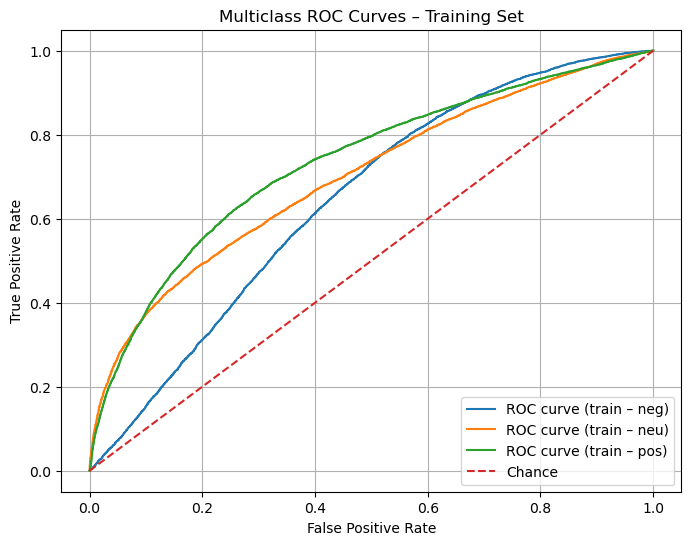

In [55]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve

# 1) Binarize the training labels for multiclass ROC (classes: 0=neg, 1=neu, 2=pos)
y_train_bin = label_binarize(y_train_sampled, classes=[0, 1, 2])


# 3) Plot ROC for each class on training set
plt.figure(figsize=(8, 6))
for i, class_name in enumerate(["neg", "neu", "pos"]):
    fpr, tpr, _ = roc_curve(y_train_bin[:, i], y_train_proba[:, i])
    plt.plot(fpr, tpr, label=f"ROC curve (train – {class_name})")

# 4) Add diagonal “chance” line
plt.plot([0, 1], [0, 1], linestyle="--", label="Chance")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC Curves – Training Set")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


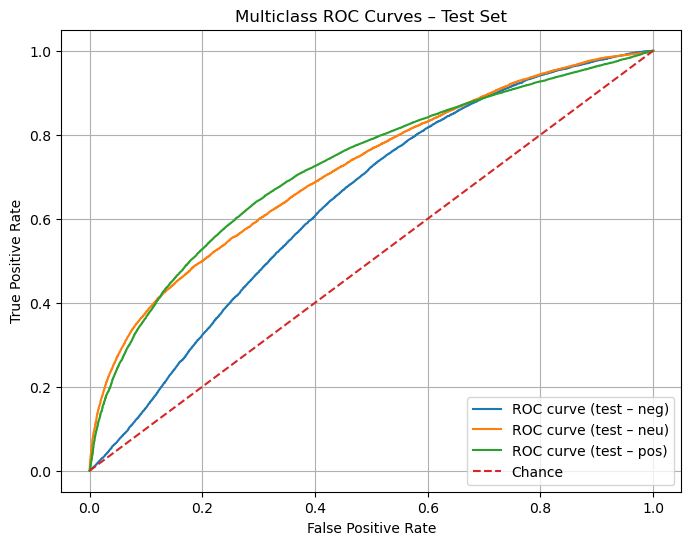

In [56]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve

# 1) Binarize the test labels for multiclass ROC (classes: 0=neg, 1=neu, 2=pos)
y_test_bin = label_binarize(y_test_cleaned, classes=[0, 1, 2])

# 3) Plot ROC for each class on test set
plt.figure(figsize=(8, 6))
for i, class_name in enumerate(["neg", "neu", "pos"]):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_test_proba[:, i])
    plt.plot(fpr, tpr, label=f"ROC curve (test – {class_name})")

# 4) Add diagonal “chance” line
plt.plot([0, 1], [0, 1], linestyle="--", label="Chance")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC Curves – Test Set")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


In [82]:
# Use cleaned data
X_train = X_train_cleaned['clean_tweet']
y_train = y_train_cleaned
X_val = X_val_cleaned['clean_tweet']
y_val = y_val_cleaned

Model Tuning (Iteration 1 with GloVe + SVM (default linear))

In [129]:
# Minimal sampling sizes for quick testing
train_sample_size = 10000
val_sample_size = 2500
test_sample_size = 2500

# Sample subsets
X_train_sampled = X_train_cleaned.sample(n=train_sample_size, random_state=42).reset_index(drop=True)
y_train_sampled = y_train_cleaned.loc[X_train_sampled.index].reset_index(drop=True)

X_val_sampled = X_val_cleaned.sample(n=val_sample_size, random_state=42).reset_index(drop=True)
y_val_sampled = y_val_cleaned.loc[X_val_sampled.index].reset_index(drop=True)

X_test_sampled = X_test_cleaned.sample(n=test_sample_size, random_state=42).reset_index(drop=True)
y_test_sampled = y_test_cleaned.loc[X_test_sampled.index].reset_index(drop=True)

# Confirm shapes
print("Sampled Shapes (Reduced):")
print("  X_train_sampled:", X_train_sampled.shape, "y_train_sampled:", y_train_sampled.shape)
print("  X_val_sampled:  ", X_val_sampled.shape,   "y_val_sampled:  ", y_val_sampled.shape)
print("  X_test_sampled: ", X_test_sampled.shape,  "y_test_sampled: ", y_test_sampled.shape)


Sampled Shapes (Reduced):
  X_train_sampled: (10000, 4) y_train_sampled: (10000,)
  X_val_sampled:   (2500, 4) y_val_sampled:   (2500,)
  X_test_sampled:  (2500, 4) y_test_sampled:  (2500,)


In [130]:
import pandas as pd
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.base import BaseEstimator, TransformerMixin
import numpy as np

def average_glove_vector(tweet, embeddings, dim=100):
    words = tweet.split()
    vectors = [embeddings[word] for word in words if word in embeddings]
    if len(vectors) == 0:
        return np.zeros(dim)
    return np.mean(vectors, axis=0)

# Add 'glove_vector' column
X_train_sampled['glove_vector'] = X_train_sampled['clean_tweet'].apply(lambda x: average_glove_vector(x, glove_embeddings))
X_val_sampled['glove_vector'] = X_val_sampled['clean_tweet'].apply(lambda x: average_glove_vector(x, glove_embeddings))




In [131]:
class GloveVectorizer(BaseEstimator, TransformerMixin):
    def __init__(self, column='glove_vector'):
        self.column = column

    def fit(self, X, y=None): return self

    def transform(self, X):
        return np.vstack(X[self.column].values)


In [132]:
pipeline = Pipeline([
    ('glove_vec', GloveVectorizer(column='glove_vector')),
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='linear', class_weight='balanced'))
])


In [133]:
param_grid = {'svm__C': [0.01, 0.1, 1, 10]}
grid_search = GridSearchCV(pipeline, param_grid, cv=3, scoring='f1_weighted', verbose=2, n_jobs=-1)
grid_search.fit(X_train_sampled, y_train_sampled)

# Evaluation
y_val_pred = grid_search.predict(X_val_sampled)
print(classification_report(y_val_sampled, y_val_pred))


Fitting 3 folds for each of 4 candidates, totalling 12 fits
              precision    recall  f1-score   support

           0       0.23      0.32      0.27       569
           1       0.15      0.37      0.21       371
           2       0.63      0.31      0.41      1560

    accuracy                           0.32      2500
   macro avg       0.34      0.33      0.30      2500
weighted avg       0.47      0.32      0.35      2500



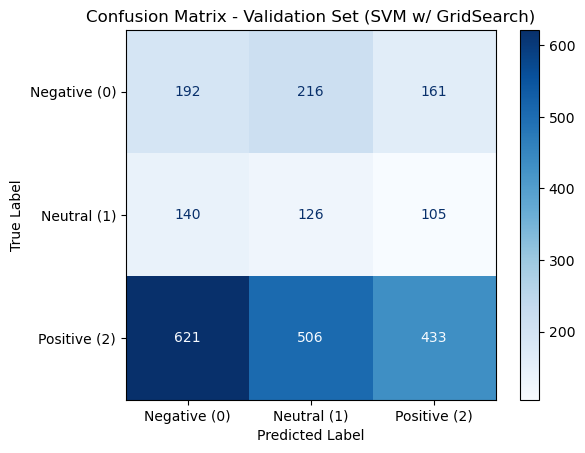

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


# Compute confusion matrix
cm = confusion_matrix(y_val_sampled, y_val_pred, labels=[0, 1, 2])

# Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negative (0)', 'Neutral (1)', 'Positive (2)'])
disp.plot(cmap=plt.cm.Blues)

plt.title("Confusion Matrix - Validation Set (SVM w/ GridSearch)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.grid(False)
plt.show()


Model Tuning – Iteration 1

What was done?

--  Used SVM with a linear kernel.

--  Embedded tweets using GloVe (100d) average vectors.

--  Added a StandardScaler for normalization.

--  Enabled class_weight='balanced' to handle class imbalance.

--  Performed GridSearchCV over C values: [0.01, 0.1, 1, 10].

--  Evaluated performance using f1_weighted scoring across 3-fold cross-validation.

Observations — What Was Going Wrong?

--  F1-scores for classes 0 (Negative) a/nd 1 (Neutral) were very low, despite balancing.

--  Most predictions were biased toward class 2 (Positive), which was easier to classify due to clearer language cues.

--  The GloVe embeddings were averaged, which may have caused loss of contextual nuance.

Iteration 2 with different SVM kernels

In [134]:
import pandas as pd
import numpy as np
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from sklearn.base import BaseEstimator, TransformerMixin
import warnings
warnings.filterwarnings("ignore")

# --- 1. Load GloVe Embeddings ---
def load_glove_embeddings(glove_path=r"C:\Users\Meet\Downloads\glove.6B\glove.6B.100d.txt"):
    embeddings = {}
    with open(glove_path, encoding='utf8') as f:
        for line in f:
            values = line.split()
            word = values[0]
            vector = np.array(values[1:], dtype='float32')
            embeddings[word] = vector
    return embeddings

glove_embeddings = load_glove_embeddings()



In [135]:
# --- 2. Compute Average GloVe Vectors ---
def compute_avg_glove_vector(text, glove_dict, dim=100):
    words = str(text).split()
    vectors = [glove_dict[word] for word in words if word in glove_dict]
    if vectors:
        return np.mean(vectors, axis=0).tolist()
    else:
        return np.zeros(dim).tolist()

In [136]:
# --- 3. Apply GloVe Vectorization ---
X_train_sampled['glove'] = X_train_sampled['clean_tweet'].apply(lambda x: compute_avg_glove_vector(x, glove_embeddings))
X_val_sampled['glove']   = X_val_sampled['clean_tweet'].apply(lambda x: compute_avg_glove_vector(x, glove_embeddings))

# --- 4. Custom Transformer to Extract 'glove' Column ---
class GloveVectorizer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None): return self
    def transform(self, X): return np.vstack(X['glove'].apply(np.array))

In [137]:
# --- 5. Build Pipeline and GridSearch ---
pipeline = Pipeline([
    ('glove_vec', GloveVectorizer()),
    ('scaler', StandardScaler()),
    ('svm', SVC(class_weight='balanced'))
])

# Tune SVM kernel and C value
param_grid = {
    'svm__kernel': ['linear', 'rbf', 'poly'],  # Try different kernels
    'svm__C': [0.1, 1, 10]                     # Try different regularization strengths
}

In [138]:
# Grid search setup
grid_search = GridSearchCV(
    pipeline,
    param_grid=param_grid,
    cv=3,
    scoring='f1_weighted',
    verbose=2,
    n_jobs=-1
)

# --- 6. Fit Model ---
grid_search.fit(X_train_sampled, y_train_sampled)

Fitting 3 folds for each of 9 candidates, totalling 27 fits


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('glove_vec', GloveVectorizer()),
                                       ('scaler', StandardScaler()),
                                       ('svm', SVC(class_weight='balanced'))]),
             n_jobs=-1,
             param_grid={'svm__C': [0.1, 1, 10],
                         'svm__kernel': ['linear', 'rbf', 'poly']},
             scoring='f1_weighted', verbose=2)

In [139]:
# --- 7. Evaluate Model on Validation Set ---
y_val_pred = grid_search.predict(X_val_sampled)
print("Best Parameters:", grid_search.best_params_)
print("\nClassification Report on Validation Set:\n")
print(classification_report(y_val_sampled, y_val_pred))

Best Parameters: {'svm__C': 10, 'svm__kernel': 'poly'}

Classification Report on Validation Set:

              precision    recall  f1-score   support

           0       0.20      0.34      0.25       569
           1       0.15      0.34      0.21       371
           2       0.62      0.28      0.38      1560

    accuracy                           0.30      2500
   macro avg       0.32      0.32      0.28      2500
weighted avg       0.45      0.30      0.33      2500



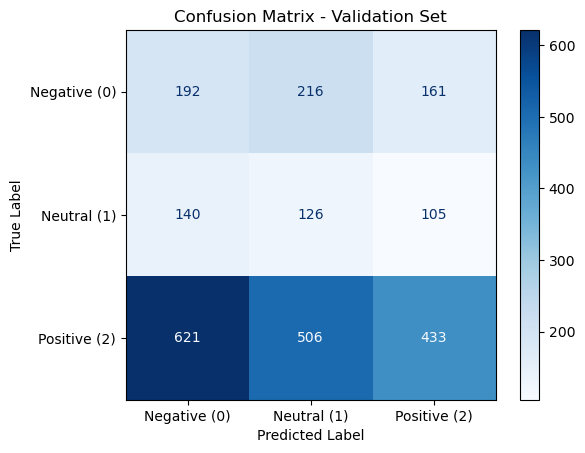

In [140]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predict on validation data
y_val_pred = grid_search.best_estimator_.predict(X_val_sampled)

# Compute confusion matrix
cm = confusion_matrix(y_val_sampled, y_val_pred, labels=[0, 1, 2])

# Display
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negative (0)', 'Neutral (1)', 'Positive (2)'])
disp.plot(cmap=plt.cm.Blues)

plt.title("Confusion Matrix - Validation Set")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.grid(False)
plt.show()


Model Tuning – Iteration 2

In this second iteration, we extended the tuning strategy by:

--  Continuing with GloVe 100d embeddings (averaged vectors)

--  Keeping StandardScaler and class_weight='balanced' in the pipeline

--  Introducing non-linear SVM kernels: linear, rbf, and poly

--  Running GridSearchCV on a parameter grid of:

--  svm__kernel: ['linear', 'rbf', 'poly']

--  svm__C: [0.1, 1, 10]

--  Applied GridSearchCV with f1_weighted scoring and 3-fold cross-validation.

--  Sampled data used for faster tuning: 10,000 for training, 2500 for validation and testing.

Observations

--  Tuning additional kernels did not significantly improve model performance.

--  The model is still biased toward predicting class 2 (Positive), though performance on class 0 improved slightly in recall.

--  poly kernel had the best result, but still struggles with subtle differences between neutral and negative.

--  The added numerical features (tweet_length, num_hashtags, lexicon_score) did not contribute significantly under current preprocessing.

Why Did Accuracy Drop After Tuning?

When we first built the model using 35,000 training samples, we got a validation accuracy of about 55%. But during tuning, the accuracy dropped to around 30%. Here’s why:

--  We used a much smaller dataset (10,000 samples) during tuning to make training faster. Less data means the model had less to learn from.

--  Some of the SVM kernels we tried (like poly) might have overfit the small dataset, which made them do worse on validation data.

--  We didn’t add any new features or improvements to the text itself — so even after tuning, the model wasn’t learning anything new.

--  The GloVe vectors were the same, and no better word representations (like BERT) were used, which limited improvement.